<a href="https://colab.research.google.com/github/OBILISETTVYSHNAVI/music-genre-prediction/blob/main/Music_Genre_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q gradio librosa tensorflow scikit-learn matplotlib pydub soundfile

# 🔑 Upload your Kaggle API key
from google.colab import files
files.upload()  # Upload kaggle.json here

# Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# ✅ Download GTZAN dataset from working source
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification
!unzip -q gtzan-dataset-music-genre-classification.zip

import os
DATA_DIR = "/content/Data/genres_original"
genres = sorted(os.listdir(DATA_DIR))
print(genres)

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
 98% 1.19G/1.21G [00:11<00:00, 200MB/s]
100% 1.21G/1.21G [00:11<00:00, 110MB/s]
['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
import os
import librosa
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

# Constants
DATA_PATH = "/content/Data/genres_original"
MAX_LEN = 130
N_MFCC = 40

# Feature extraction
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, duration=30)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        if mfcc.shape[1] < MAX_LEN:
            mfcc = np.pad(mfcc, ((0, 0), (0, MAX_LEN - mfcc.shape[1])), mode='constant')
        else:
            mfcc = mfcc[:, :MAX_LEN]
        return mfcc
    except Exception as e:
        print(f"Error in {file_path}: {e}")
        return None

# Load data
X, y = [], []
for genre in os.listdir(DATA_PATH):
    genre_path = os.path.join(DATA_PATH, genre)
    if not os.path.isdir(genre_path):
        continue
    for file in tqdm(os.listdir(genre_path), desc=f"Processing {genre}"):
        if file.endswith((".wav", ".mp3", ".mp4")):
            path = os.path.join(genre_path, file)
            features = extract_features(path)
            if features is not None:
                X.append(features)
                y.append(genre)

# Preprocessing
X = np.array(X)[..., np.newaxis]
y = np.array(y)
encoder = LabelEncoder()
y_encoded = to_categorical(encoder.fit_transform(y))
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(N_MFCC, MAX_LEN, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(np.unique(y)), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32)

# Save model
model.save("genre_cnn.h5")
print("✅ Model saved as genre_cnn.h5")


Processing jazz:  63%|██████▎   | 63/100 [00:05<00:05,  6.94it/s]/tmp/ipython-input-10-3180485501.py:18: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(file_path, duration=30)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Processing jazz:  66%|██████▌   | 66/100 [00:05<00:05,  6.48it/s]

Error in /content/Data/genres_original/jazz/jazz.00054.wav: 


Processing pop: 100%|██████████| 100/100 [00:07<00:00, 12.84it/s]


Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.2483 - loss: 3.4937 - val_accuracy: 0.2050 - val_loss: 7.0545
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step - accuracy: 0.4874 - loss: 1.4930 - val_accuracy: 0.2800 - val_loss: 3.2902
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 222ms/step - accuracy: 0.6255 - loss: 1.1498 - val_accuracy: 0.3000 - val_loss: 2.2761
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - accuracy: 0.6841 - loss: 0.8551 - val_accuracy: 0.4250 - val_loss: 1.9218
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.7811 - loss: 0.6043 - val_accuracy: 0.4200 - val_loss: 1.8699
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - accuracy: 0.8438 - loss: 0.4248 - val_accuracy: 0.3850 - val_loss: 2.0735
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.8840 - loss: 0.3392 - val_accuracy: 0.4750 - val_loss: 1.6180
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 217ms/step - accuracy: 0.9471 - loss: 0.1951 - val_accuracy:

✅ Model saved as genre_cnn.h5


In [ ]:
import gradio as gr
import os
import numpy as np
import tensorflow as tf
import librosa
import librosa.display
from pydub import AudioSegment
import tempfile
import matplotlib.pyplot as plt

# ✅ 3. GENRE LABELS
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']

# ✅ 4. LOAD MODEL
model = tf.keras.models.load_model("genre_cnn.h5")

# ✅ 5. AUDIO PREPROCESSING FUNCTION
def preprocess_audio(file):
    ext = os.path.splitext(file.name)[1].lower()
    with tempfile.NamedTemporaryFile(delete=False, suffix='.wav') as tmpfile:
        if ext == '.mp3':
            sound = AudioSegment.from_mp3(file.name)
            sound.export(tmpfile.name, format='wav')
        elif ext == '.mp4':
            sound = AudioSegment.from_file(file.name, format="mp4")
            sound.export(tmpfile.name, format='wav')
        else:
            tmpfile.write(file.read())
            tmpfile.flush()

        y, sr = librosa.load(tmpfile.name, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc = mfcc.T
        if mfcc.shape[0] < 1300:
            mfcc = np.pad(mfcc, ((0, 1300 - mfcc.shape[0]), (0, 0)))
        else:
            mfcc = mfcc[:1300]

        return mfcc[np.newaxis, ..., np.newaxis]


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Classification Report:
              precision    recall  f1-score   support

       blues       0.47      0.47      0.47        15
   classical       0.92      0.89      0.91        27
     country       0.60      0.38      0.46        24
       disco       0.60      0.14      0.22        22
      hiphop       0.53      0.53      0.53        19
        jazz       0.44      0.64      0.52        11
       metal       0.86      0.78      0.82        23
         pop       0.44      0.70      0.54        20
      reggae       0.43      0.71      0.54        21
        rock       0.44      0.39      0.41        18

    accuracy                           0.57       200
   macro avg       0.57      0.56      0.54       200
weighted avg       0.60      0.57      0.56       200



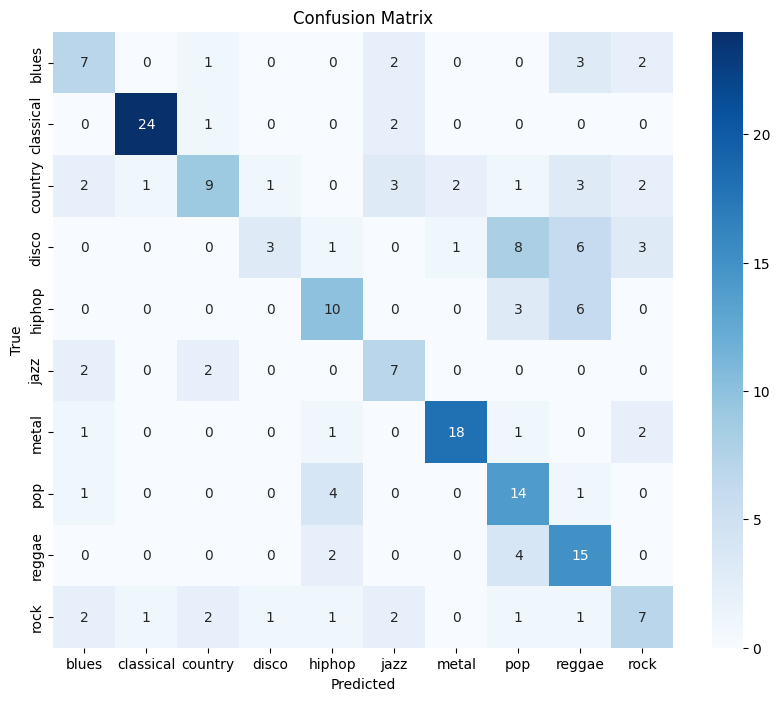

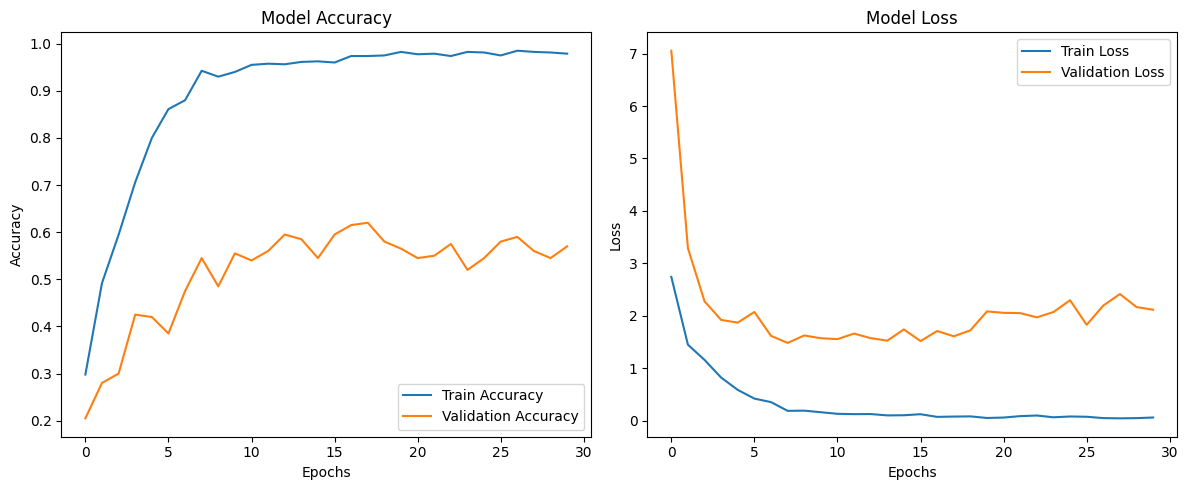

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf

# ✅ Assume model has been trained and we have:
# - history from model.fit()
# - X_test, y_test (y_test is one-hot encoded)
# - original y (string labels)

# Label encode and convert one-hot encoded test labels back to class indices
le = LabelEncoder()
le.fit(y)  # y must be the original list of genre labels before to_categorical
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

# ✅ Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# ✅ Accuracy and Loss Plots
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


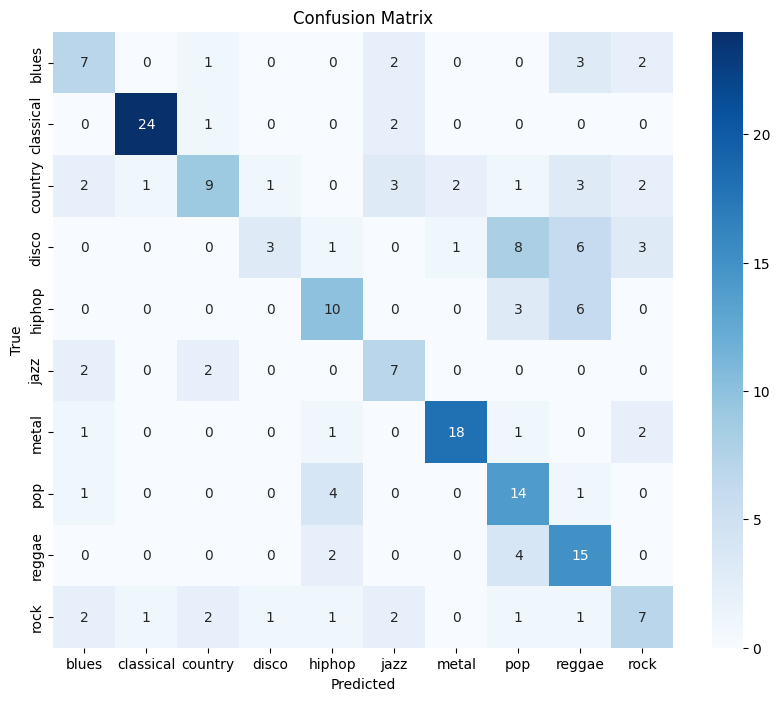

In [ ]:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Recreate if necessary
le = LabelEncoder()
le.fit(y)  # `y` must be the original label array before one-hot encoding

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Save the Streamlit app code into app.py
app_code = """
import streamlit as st
import librosa
import librosa.display
import numpy as np
import tensorflow as tf
import os
from pydub import AudioSegment
import tempfile
import matplotlib.pyplot as plt

# Genre labels (adjust if your model differs)
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']

# Load model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("genre_cnn.h5")

model = load_model()

# Audio preprocessing
def preprocess_audio(file):
    # Convert to wav if needed
    ext = os.path.splitext(file.name)[1].lower()
    with tempfile.NamedTemporaryFile(delete=False, suffix='.wav') as tmpfile:
        if ext == '.mp3':
            sound = AudioSegment.from_mp3(file)
            sound.export(tmpfile.name, format='wav')
        elif ext == '.mp4':
            sound = AudioSegment.from_file(file, format="mp4")
            sound.export(tmpfile.name, format='wav')
        else:
            tmpfile.write(file.read())
            tmpfile.flush()

        y, sr = librosa.load(tmpfile.name, duration=30)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        mfcc = mfcc.T
        if mfcc.shape[0] < 1300:
            mfcc = np.pad(mfcc, ((0, 1300 - mfcc.shape[0]), (0, 0)))
        else:
            mfcc = mfcc[:1300]

        return mfcc[np.newaxis, ..., np.newaxis]

# 🎧 Streamlit App Interface
st.set_page_config(page_title="🎶 Music Genre Classifier", layout="centered")
st.title("🎧 Music Genre Classification App")
st.markdown("Upload an audio file (.mp3, .mp4, or .wav) to predict its genre using a CNN model.")

audio_file = st.file_uploader("Upload audio", type=["wav", "mp3", "mp4"])

if audio_file is not None:
    st.audio(audio_file, format='audio/wav')
    st.write(f"✅ File name: {audio_file.name}")
    st.write(f"🧪 Detected MIME type: {audio_file.type}")

    with st.spinner("Processing audio..."):
        features = preprocess_audio(audio_file)
        prediction = model.predict(features)[0]
        predicted_index = np.argmax(prediction)
        confidence = prediction[predicted_index] * 100
        predicted_genre = GENRES[predicted_index]

    st.success(f"🎵 Predicted Genre: **{predicted_genre.upper()}** ({confidence:.2f}%)")

    # Show genre probability chart
    st.subheader("📊 Genre Confidence")
    fig, ax = plt.subplots()
    ax.bar(GENRES, prediction, color='skyblue')
    ax.set_ylabel("Confidence")
    ax.set_xticklabels(GENRES, rotation=45)
    st.pyplot(fig)
"""

# Write to a file
with open("app.py", "w") as f:
    f.write(app_code)

# Download the file
from google.colab import files
files.download("app.py")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Create the .streamlit directory
!mkdir -p .streamlit

# Create the config.toml file with required settings
config = """
[server]
headless = true
enableCORS = false
port = 7860
"""
with open(".streamlit/config.toml", "w") as f:
    f.write(config)

print("✅ .streamlit/config.toml file created successfully.")


✅ .streamlit/config.toml file created successfully.
